# Air Fryer Demand Estimation — Pricing Analyst Notebook

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_FILE = "air_fryers_clean_brand_year.csv"

if Path(DATA_FILE).exists():
    data_path = Path(DATA_FILE)
elif (Path("/mnt/data") / DATA_FILE).exists():
    data_path = Path("/mnt/data") / DATA_FILE
else:
    raise FileNotFoundError(f"Could not find {DATA_FILE}. Put it in the same folder as this notebook.")

df = pd.read_csv(data_path)
feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share",
]

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

df.head()


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


## 1. Re-estimate the demand model needed for pricing

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

y = df["log_brand_share"]

brand_dummies = pd.get_dummies(df["brand"], prefix="brand", drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df["year"].astype(str), prefix="year", drop_first=True, dtype=int)

X = pd.concat(
    [df[["avg_price", "avg_rating"] + feature_cols], brand_dummies, year_dummies],
    axis=1
)

model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_,
})

price_coef = coef_table.loc[coef_table["feature"] == "avg_price", "coefficient"].iloc[0]

print("R-squared:", r2)
print("Estimated price coefficient:", price_coef)

display(coef_table.sort_values("coefficient").reset_index(drop=True))

R-squared: 0.763453950091436
Estimated price coefficient: -0.03766765298429383


,feature,coefficient
0,dual_basket_share,-9.509686
1,rotisserie_share,-5.674054
2,year_2022,-0.098860
3,avg_price,-0.037668
4,year_2023,-0.003307
5,year_2021,0.041900
6,year_2020,0.119071
7,brand_dash,0.176655
8,avg_rating,0.287517
9,brand_ultrean,0.942399


### Interpretation: pricing input

The pricing analysis uses the same demand model as the data scientist notebook. The key input is the estimated price coefficient, **-0.0377**. Because it is negative, the implied demand slope will also be negative for every brand-year.

That negative slope is required for the markup formula to make business sense. If demand did not fall when price rose, the inferred unit-cost calculation would not be reliable.

## 2. Compute demand slope, unit cost, markup, and profit index

In [4]:
results = df.copy()
results["predicted_log_share"] = predicted_log_share

# Demand slope from the assignment formula.
results["demand_slope"] = price_coef * results["brand_share"] * (1 - results["brand_share"])

# Pricing first-order condition rearranged to infer unit cost.
results["unit_cost"] = results["avg_price"] + results["brand_share"] / results["demand_slope"]

# Markup and share-weighted profit index.
results["markup"] = results["avg_price"] - results["unit_cost"]
results["average_profit"] = results["brand_share"] * results["markup"]

# This should be near zero if the first-order condition is implemented correctly.
results["profit_derivative"] = results["demand_slope"] * results["markup"] + results["brand_share"]

display(results[[
    "year", "brand", "avg_price", "brand_share", "demand_slope",
    "unit_cost", "markup", "average_profit", "profit_derivative"
]].round(4).head(12))

display(results[["demand_slope", "unit_cost", "markup", "average_profit", "profit_derivative"]].describe().round(4))

,year,brand,avg_price,brand_share,demand_slope,unit_cost,markup,average_profit,profit_derivative
0,2019,chefman,72.9637,0.0760,-0.0026,44.2317,28.7320,2.1841,-0.0
1,2019,cosori,159.9900,0.0007,-0.0000,133.4226,26.5674,0.0194,0.0
2,2019,cuisinart,229.4653,0.1072,-0.0036,199.7300,29.7353,3.1873,-0.0
3,2019,dash,55.1763,0.1997,-0.0060,22.0029,33.1734,6.6254,-0.0
4,2019,gowise usa,83.5756,0.2922,-0.0078,46.0685,37.5070,10.9590,0.0
5,2019,instant_pot,78.0199,0.0158,-0.0006,51.0461,26.9738,0.4258,0.0
6,2019,ninja,112.1584,0.1926,-0.0059,79.2766,32.8818,6.3338,0.0
7,2019,nuwave,151.0999,0.0321,-0.0012,123.6714,27.4285,0.8806,-0.0
8,2019,oster,191.9437,0.0336,-0.0012,164.4737,27.4700,0.9220,-0.0
9,2019,ultrean,80.6247,0.0501,-0.0018,52.6771,27.9476,1.3996,0.0


,demand_slope,unit_cost,markup,average_profit,profit_derivative
count,50.0000,50.0000,50.0000,50.0000,50.0
mean,-0.0032,93.1022,29.7039,3.1559,0.0
std,0.0020,51.6961,2.6158,2.6158,0.0
min,-0.0078,22.0029,26.5674,0.0194,-0.0
25%,-0.0046,53.1591,27.9524,1.4044,-0.0
50%,-0.0027,70.0383,28.8133,2.2653,0.0
75%,-0.0018,123.5619,30.9569,4.4089,0.0
max,-0.0000,199.7300,37.5070,10.9590,0.0


### Interpretation: pricing calculations

The average inferred unit cost is about **$93.10**, while the average markup is about **$29.70**. Markups are positive across brand-years because estimated unit cost is below observed price.

The `profit_derivative` column is essentially zero, which is a check that the first-order pricing formula was implemented correctly. The `average_profit` measure is not total dollar profit. It is a **share-weighted profit index**, so it rewards brands that have both high markup and high share.

## 3. Brand-level pricing summary

In [5]:
pricing_summary = (
    results.groupby("brand")
      .agg(
          avg_price=("avg_price", "mean"),
          avg_share=("brand_share", "mean"),
          unit_cost=("unit_cost", "mean"),
          markup=("markup", "mean"),
          average_profit=("average_profit", "mean"),
      )
      .sort_values("average_profit", ascending=False)
)

display(pricing_summary.round(3))

,avg_price,avg_share,unit_cost,markup,average_profit
brand,,,,,
ninja,145.343,0.192,112.488,32.854,6.306
instant_pot,104.461,0.175,71.903,32.558,6.010
gowise usa,87.455,0.138,56.301,31.154,4.606
dash,57.479,0.098,27.937,29.542,2.994
chefman,90.938,0.095,61.569,29.369,2.821
ultrean,78.115,0.092,48.786,29.329,2.781
cuisinart,223.947,0.086,194.896,29.051,2.503
cosori,114.268,0.049,86.283,27.985,1.437
nuwave,137.024,0.051,109.054,27.971,1.423


### Interpretation: most profitable brands

Using the share-weighted profit index, the strongest brands are **ninja (6.306), instant_pot (6.010), gowise usa (4.606)**. These brands are not necessarily the cheapest or the most expensive; they do well because they combine meaningful market share with positive markups.

The highest average prices are **cuisinart ($223.95), oster ($189.03), ninja ($145.34)**, but high price alone does not guarantee the highest profit index. For example, Cuisinart is expensive, but its average share is lower than Ninja or Instant Pot, so its share-weighted profit index is lower.

## 4. Visualize markups, unit costs, and profit

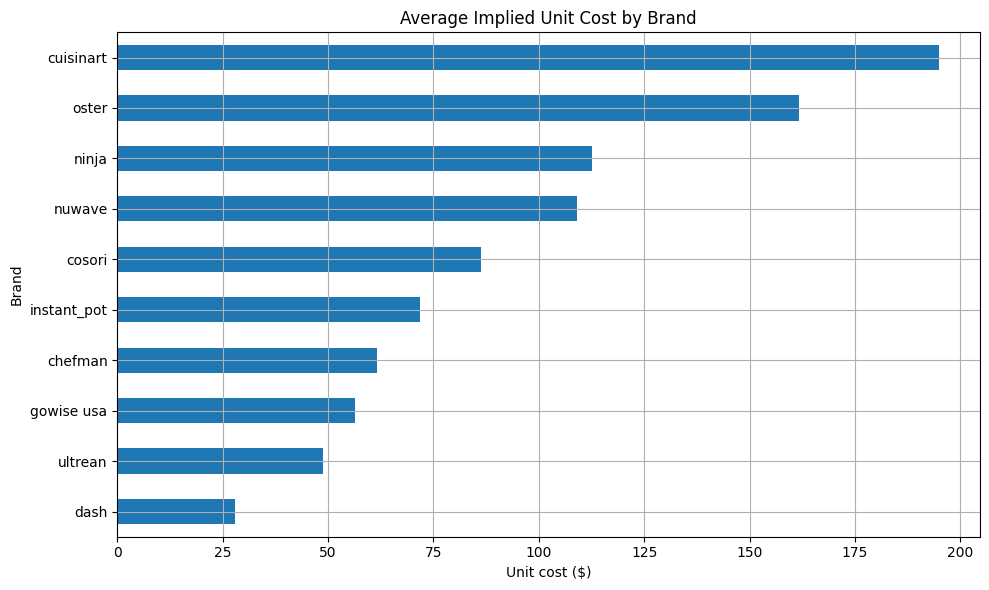

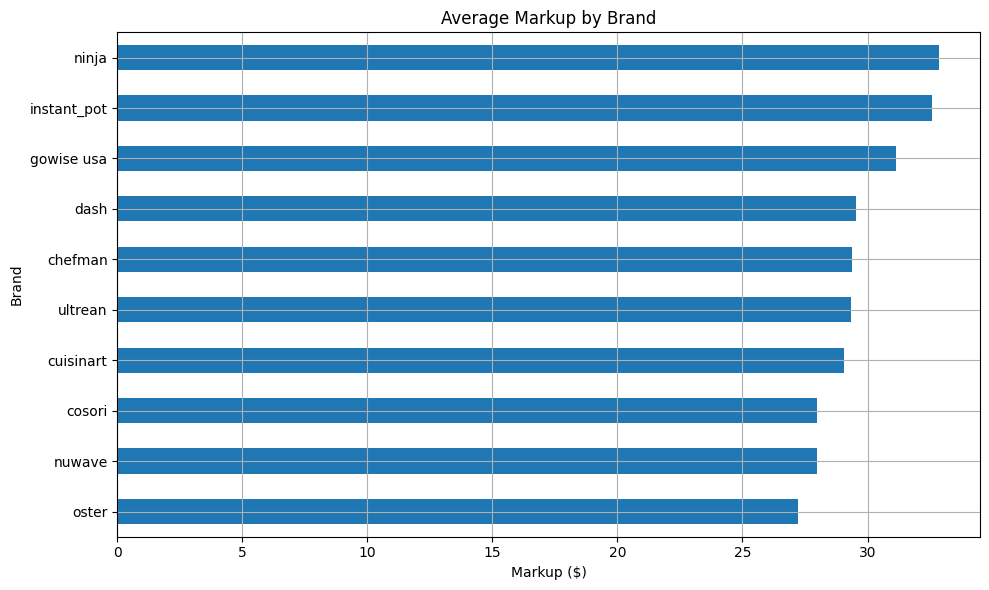

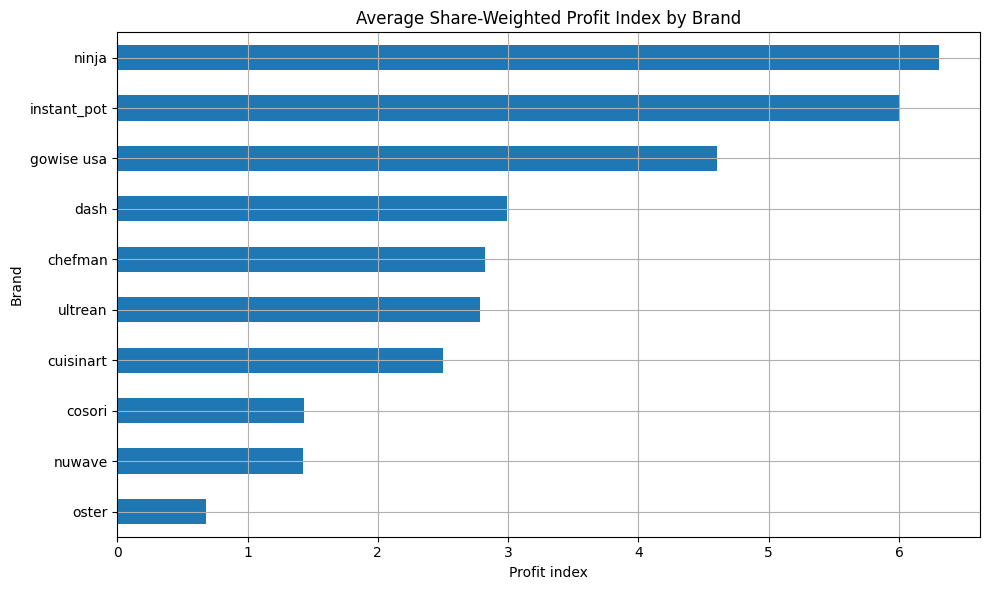

In [6]:
for col, title, ylabel in [
    ("unit_cost", "Average Implied Unit Cost by Brand", "Unit cost ($)"),
    ("markup", "Average Markup by Brand", "Markup ($)"),
    ("average_profit", "Average Share-Weighted Profit Index by Brand", "Profit index"),
]:
    ax = pricing_summary.sort_values(col)[col].plot(kind="barh")
    ax.set_title(title)
    ax.set_xlabel(ylabel)
    ax.set_ylabel("Brand")
    plt.tight_layout()
    plt.show()

### Interpretation: pricing visuals

The unit-cost chart mostly follows the price positioning of brands: higher-priced brands tend to have higher inferred costs. The markup chart is much more compressed than the price chart, meaning the model does not imply that premium brands simply keep all of the extra price as profit. Instead, a large part of high price is interpreted as higher cost or higher-quality positioning.

The profit-index chart highlights the business importance of market share. Ninja and Instant Pot stand out because their demand is large enough that even similar markups translate into stronger share-weighted profit.

## 5. Price vs. cost and rating vs. cost

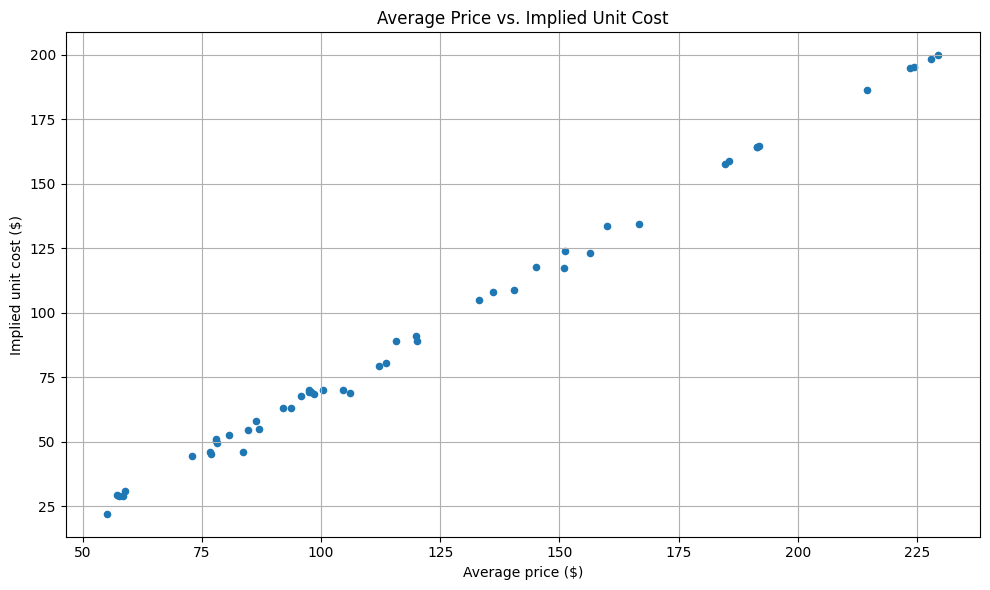

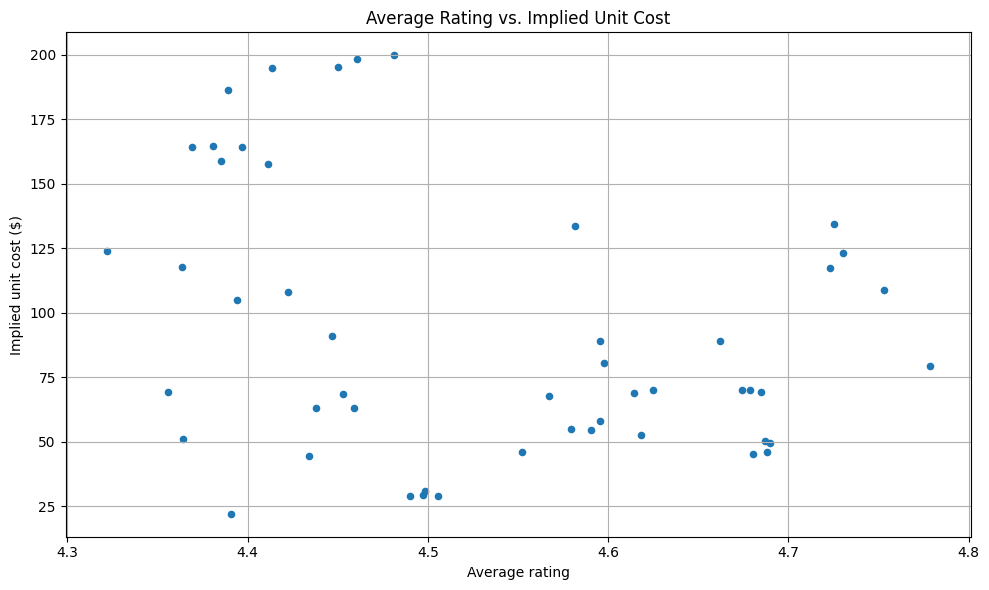

,avg_price,avg_rating,brand_share,unit_cost,markup,average_profit
avg_price,1.000,-0.294,-0.189,0.999,-0.182,-0.182
avg_rating,-0.294,1.000,0.472,-0.314,0.456,0.456
brand_share,-0.189,0.472,1.000,-0.237,0.995,0.995
unit_cost,0.999,-0.314,-0.237,1.000,-0.231,-0.231
markup,-0.182,0.456,0.995,-0.231,1.000,1.000
average_profit,-0.182,0.456,0.995,-0.231,1.000,1.000


In [7]:
ax = results.plot(kind="scatter", x="avg_price", y="unit_cost")
ax.set_title("Average Price vs. Implied Unit Cost")
ax.set_xlabel("Average price ($)")
ax.set_ylabel("Implied unit cost ($)")
plt.tight_layout()
plt.show()

ax = results.plot(kind="scatter", x="avg_rating", y="unit_cost")
ax.set_title("Average Rating vs. Implied Unit Cost")
ax.set_xlabel("Average rating")
ax.set_ylabel("Implied unit cost ($)")
plt.tight_layout()
plt.show()

display(results[["avg_price", "avg_rating", "brand_share", "unit_cost", "markup", "average_profit"]].corr().round(3))

### Interpretation: cost patterns

Average price and inferred unit cost move very closely together. This suggests that the model is treating expensive brands partly as brands with more expensive products, not just brands with unusually high margins.

Ratings have a weaker relationship with inferred cost. Higher-rated brands may earn stronger demand, but rating alone is not the same thing as cost. Brand reputation, product format, and market share also matter.

## 6. Market competitiveness and business recommendation

In [8]:
market_summary = {
    "average_price": results["avg_price"].mean(),
    "average_unit_cost": results["unit_cost"].mean(),
    "average_markup": results["markup"].mean(),
    "min_markup": results["markup"].min(),
    "max_markup": results["markup"].max(),
    "average_profit_index": results["average_profit"].mean(),
}
display(pd.Series(market_summary).round(3))

# Save a results table that can be used in the presentation.
results.to_csv("air_fryer_pricing_results_by_brand_year.csv", index=False)
pricing_summary.to_csv("air_fryer_pricing_summary_by_brand.csv")
print("Saved: air_fryer_pricing_results_by_brand_year.csv")
print("Saved: air_fryer_pricing_summary_by_brand.csv")

average_price           122.806
average_unit_cost        93.102
average_markup           29.704
min_markup               26.567
max_markup               37.507
average_profit_index      3.156
dtype: float64

Saved: air_fryer_pricing_results_by_brand_year.csv
Saved: air_fryer_pricing_summary_by_brand.csv


### Final Pricing Analyst interpretation

The air fryer market shows positive markups, with an average implied markup of about **$29.70**. However, the markup range is relatively tight, from about **$26.57** to **$37.51**, which does not suggest that one brand is dramatically more marked up than all others in this simplified model.

From a business perspective, **Ninja** and **Instant Pot** look like the strongest performers because they combine high market share with healthy markups. **Cuisinart** and **Oster** look more premium, but their smaller shares reduce their share-weighted profit index.

Overall, this market looks competitive in the sense that multiple brands are active and shares move over time. Still, strong brands can maintain meaningful markups, especially when they combine good ratings, recognizable brand names, and enough market share. The main recommendation is that brands should not only compete by lowering price; they should also protect ratings, product positioning, and features that support demand.